# TP3 : Analyse en composantes principales (PCA)

Importez les bibliothèques suivantes.

In [1]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

Le TP précédent portait sur le K-clustering. Le présent TP utilisant les résultats de ce dernier, voici une cellule définissant la classe `MyKMeans` ainsi que la fonction `accuracy(labels)`.

In [2]:
def assign_clusters(data,centroids):
    distances = np.linalg.norm(data[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)

def random_centroids(data,k):
    indices = np.random.choice(data.shape[0],k,replace=False)
    centroids = data[indices]
    return centroids

def update_centroids(data,k, labels):
    new_centroids = np.zeros((k, data.shape[1]))
    for i in range(k):
        points_in_cluster = data[labels == i]
            
        if len(points_in_cluster) > 0:
            new_centroids[i] = points_in_cluster.mean(axis=0)
        else:
            new_centroids[i] = data[np.random.choice(len(data))]
                
    return new_centroids

class MyKMeans:
    def __init__(self, n_clusters, max_iter=100, tol=1e-4):
        self.k = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        
        self.centroids = None
        self.labels = None

    def fit(self, data):
        # 1. Init
        self.centroids = random_centroids(data,self.k)
        
        for i in range(self.max_iter):
            old_centroids = self.centroids.copy()
            self.labels = assign_clusters(data, self.centroids)
            self.centroids = update_centroids(data, self.k, self.labels)
            
            diff = np.linalg.norm(self.centroids - old_centroids)
            if diff < self.tol:
                print(f"Convergence atteinte à l'itération {i}")
                break
        else:
            print(f"Arrêt : Max itérations ({self.max_iter}) atteintes.")
            
        return self

def accuracy(labels):
    ct = pd.crosstab(labels, y)
    row_maxes = ct.max(axis=1)
    sum_of_maxes = row_maxes.sum()
    total_elements = ct.values.sum()
    proportion = sum_of_maxes / total_elements
    return proportion

Nous avons également besoin de la fonction affichant une image ou une liste d'images (au format 784 pixels).

In [3]:
def display_image(source):
    if len(source) == 784:
        images = [source]
    elif len(source[0]) == 784:
        images = source
    else:
        print("error")
    
    l = len(images)
    c = math.ceil(l / 3)
    fig, axes = plt.subplots(c, 3, figsize=(12, 5))

    for i, ax in enumerate(axes.flat):
        if i < l:
            img = images[i].reshape(28, 28)
            ax.imshow(img, cmap='gray')
            ax.set_title(f"Image {i + 1}")
        ax.axis('off')

Enfin, importez les jeux de données.

In [4]:
## from google.colab import files
## data_to_load1 = files.upload()
## import io
## df_pixels = pd.read_csv(io.BytesIO(data_to_load1['pixels.csv']))

df_pixels = pd.read_csv("pixels.csv")
X = df_pixels.to_numpy(dtype="uint8")
df_label = pd.read_csv("labels.csv")
y = df_label["label"].values

L'objectif de ce TP va consister en la définition progressive (par Monkey-Patching) d'une classe `MyPCA` implémentant l'alogirthme d'analyse en composantes principales. 

In [5]:
class MyPCA:
    def __init__(self, n_components, standardize=False):
        
        self.n_components = n_components
        self.standardize = standardize
        
        self.mean = None
        self.std = None
        self.components = None
        self.explained_variance = None
        self.total_variance = None
        self.prepared_matrix = None

print("Classe initialisée.")

Classe initialisée.


## Exercice 1 

1. La première étape est celle de préparation des données. Il existe deux versions de la PCA : la PCA sur la matrice de covariance (la matrice de données est centrée) et la PCA sur la matrice de corrélation (la matrice de données est centrée et réduite). Construisez une fonction `prepare_data(data,standardize=False)`qui renvoie une liste `prepared_data, mean, std' où:

- `prepared_data` est la matrice de données préparée pour la PCA (le booléen `standardize` determine quelle version est utilisée),
- `mean` est la donnée moyenne,
- `std` est l'écart-type (il faut la modifier légèrement ($0.00000001$ par exemple) pour assurer qu'elle n'est jamais 0). 

In [6]:
def prepare_data(data,standardize=False):
    mean = data.mean(axis=0)
    prepared_data = data - mean

    if standardize:
        std = data.std(axis=0)
        std = np.where(std == 0, 0.00000001, std)
        prepared_data = prepared_data / std
    else:
        std = np.ones(data.shape[1])

    return prepared_data, mean, std

2. Une fois la matrice de données préparée, on l'utilise pour calculer la comatrice (matrice de covariance ou matrice de corrélation). Construisez une fonction `compute_comatrix(data_prepared)` renvoyant cette comatrice.

In [7]:
def compute_comatrix(data_prepared):
    return (1/(data_prepared.shape[0]-1))*np.matmul(np.transpose(data_prepared),(data_prepared))

## Exercice 2 

Une fois la comatrice calculée, on opère une décomposition spectrale pour récupérer ses valeurs propres et ses vecteurs propres. On peut ensuite choisir les $n$ composantes les plus importantes. Construisez une fonction `get_principal_components(comatrix, n_components)` qui renvoie une liste `top_eigenvalues, top_eigenvectors, total` où :

- `top_eigenvalues` est le vecteur de $n$ plus granges valeurs propres ordonnées de la plus petites à la plus grandes,
- `top_eigenvectors` est la matrice où chacune des $n$ lignes correspond à un vecteur propre et où ils sont ordonnés dans l'ordre correspondant à leurs valeurs propres respectives,
- `total` est la somme de toutes les valeurs propres.

Attention à l'ordre et aux dimensions de vos objets ! Utilisez la fonction `np.linalg.eigh` (**[documentation](https://numpy.org/doc/2.1/reference/generated/numpy.linalg.eigh.html#numpy.linalg.eigh)**).

In [1]:
def get_principal_components(comatrix,n_components):
    eignvalues,eignvectors = np.linalg.eigh(comatrix)
    eignvalues_i= np.argsort(eignvalues)
    index = eignvalues_i[-n_components:]
    top_eigenvalues= eignvalues[index]
    top_eigenvectors = eignvectors[:, index].T
    total = eignvalues.sum()
    return top_eigenvalues[::-1], top_eigenvectors, total

## Exercice 3 

Nous allons maintenant achever la définition de la classe `MyPCA`.

1. Construisez et attribuer à `MyPCA` une fonction `fit(self,data)` appliquant une PCA à la matrice `data`. Il va s'agir d'assigner les 6 attributs de la classe `MyPCA` qui ne l'ont pas été à l'initialisation.

In [9]:
def fit(self, data):
    self.prepared_matrix, self.mean, self.std = prepare_data(data, self.standardize)
    comatrix = compute_comatrix(self.prepared_matrix)
    self.explained_variance, self.components, self.total_variance = get_principal_components(comatrix, self.n_components)
    return self

MyPCA.fit = fit

2. Construisez et attribuez à `MyPCA` une fonction `transform(self,data)` renvoyant la projection de la matrice `data` dans l'espace des composantes principales de l'instance de la classe.

In [10]:
def transform(self, data):
    data_prepared = (data-self.mean)/self.std
    data_projected = np.matmul(data_prepared, self.components.T)
    return data_projected

MyPCA.transform = transform

3. Construisez et attribuez à `MyPCA` une fonction `inverse_transform(self,data_projected)` renvoyant la reconstruction dans l'espace original d'une matrice de données vivant dans l'espace des composantes principales de l'instance de la classe. 

In [11]:
def inverse_transform(self,data_projected):
    data_reconstructed = np.matmul(data_projected, self.components)
    data_original = data_reconstructed * self.std + self.mean
    return data_original
MyPCA.inverse_transform = inverse_transform

## Exercice 4 

1. Créez une instance de la classe `MyPCA` afin de faire une PCA sur nos données (`X`) avec 6 composantes principles. Affichez les images correspondants aux 6 composantes principales.

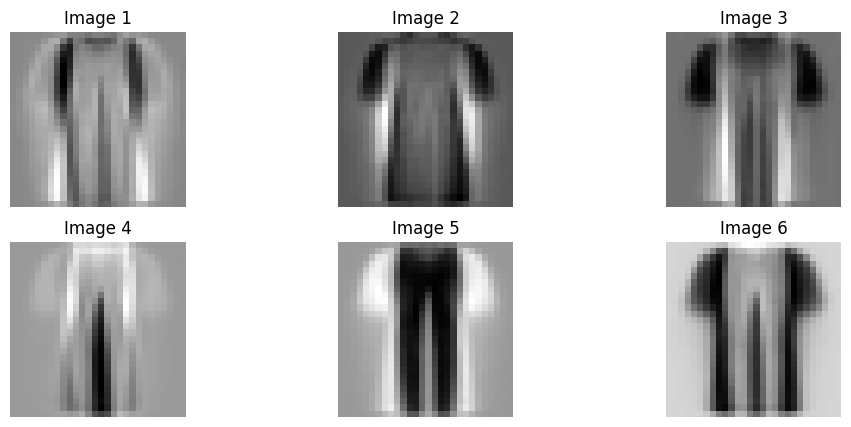

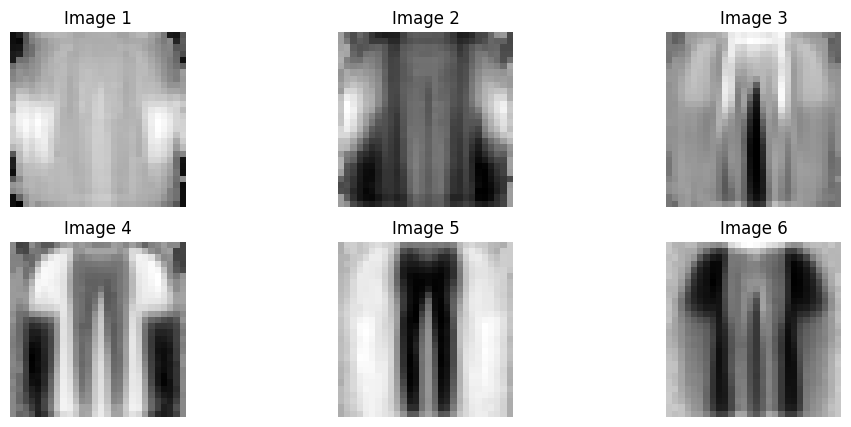

In [12]:
pca = MyPCA(n_components=6)
pca.fit(X)
display_image(pca.components)

# version exo 7
pca_std = MyPCA(n_components=6, standardize=True)
pca_std.fit(X)
display_image(pca_std.components)


2. Dessiner un graphique représentant, pour $i$ allant de 1 à 100, la part de la variance expliquée par les $i$ premières composantes principales. Utilisez `plt.plot` (**[documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html)**).

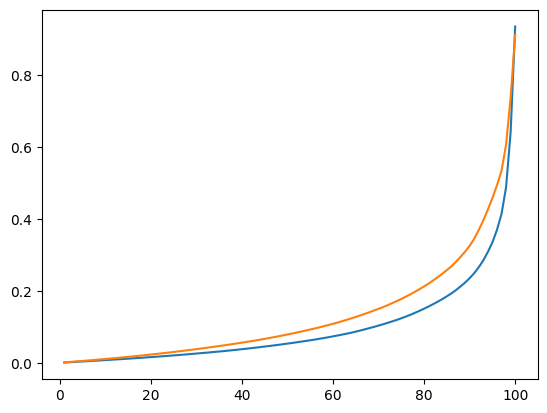

In [13]:
pca_100=MyPCA(n_components=100)
pca_100.fit(X)
variance_pour=pca_100.explained_variance/pca_100.total_variance
variance_cum= np.cumsum(variance_pour)
plt.plot(range(1, 101), variance_cum)

# version exo 7
pca_100_std = MyPCA(n_components=100, standardize=True)
pca_100_std.fit(X)
variance_pour_std = pca_100_std.explained_variance / pca_100_std.total_variance
variance_cum_std = np.cumsum(variance_pour_std)
plt.plot(range(1, 101), variance_cum_std)
plt.show()


3. Choisissez une image dans nos données. Affichez là avec ses compressions (projection puis reconstruction) dans les $i$ premières composantes principales, pour $i$ prenant les valeurs 1,3,5,10,25,50,75 et 100.

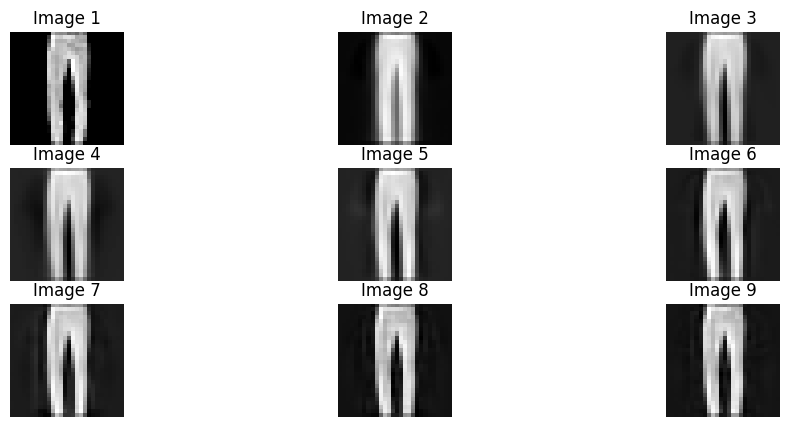

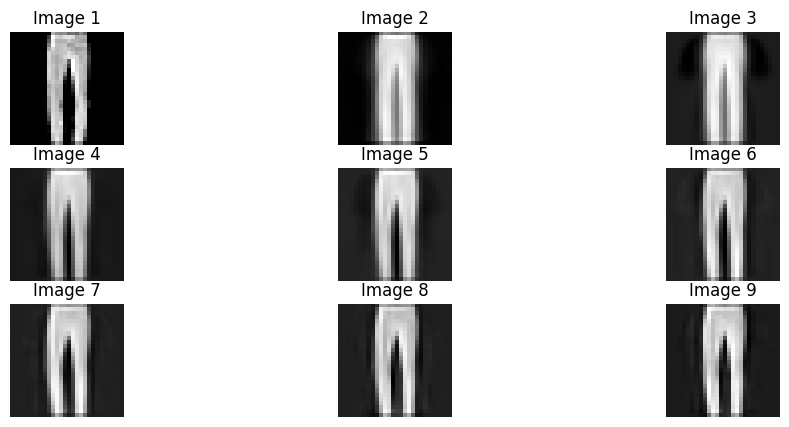

In [14]:
image_index = 0
image_originale = X[image_index]

composantes = [1, 3, 5, 10, 25, 50, 75, 100]
images_a_afficher = [image_originale]

for n in composantes:
    pca_n = MyPCA(n_components=n)
    pca_n.fit(X)
    image_projetee = pca_n.transform(image_originale.reshape(1, -1))
    image_reconstruite = pca_n.inverse_transform(image_projetee)
    images_a_afficher.append(image_reconstruite[0])
    
display_image(images_a_afficher)

# version exo 7
image_index = 0
image_originale = X[image_index]
composantes = [1, 3, 5, 10, 25, 50, 75, 100]
images_a_afficher_std = [image_originale]

for n in composantes:
    pca_n_std = MyPCA(n_components=n, standardize=True)
    pca_n_std.fit(X)
    image_projetee = pca_n_std.transform(image_originale.reshape(1, -1))
    image_reconstruite = pca_n_std.inverse_transform(image_projetee)
    images_a_afficher_std.append(image_reconstruite[0])
    
display_image(images_a_afficher_std)

## Exercice 5 

1. Utilisez la classe `MyPCA` pour projeter `X` sur deux dimensions. Visualisez le résultat dans un nuage de points avec `plt.scatter` (**[documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html#matplotlib.pyplot.scatter)**).

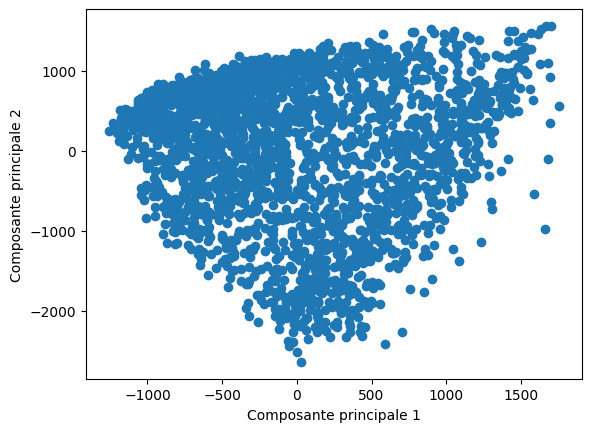

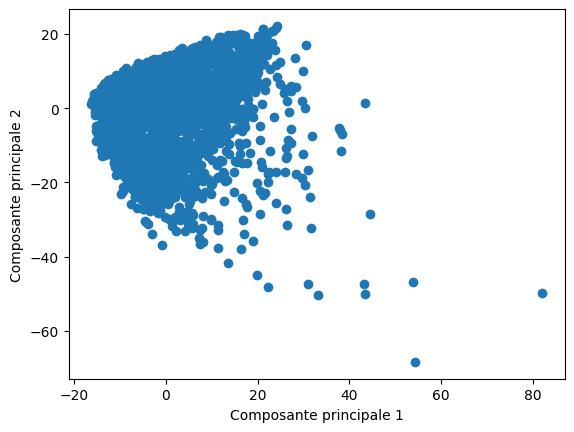

In [15]:
pca_2 = MyPCA(n_components=2)
pca_2.fit(X)
X_projected = pca_2.transform(X)
plt.scatter(X_projected[:, 0], X_projected[:, 1])
plt.xlabel('Composante principale 1')
plt.ylabel('Composante principale 2')
plt.show()


# version exo 7

pca_3 = MyPCA(n_components=2,standardize=True)
pca_3.fit(X)
X_projected_1 = pca_3.transform(X)
plt.scatter(X_projected_1[:, 0], X_projected_1[:, 1])
plt.xlabel('Composante principale 1')
plt.ylabel('Composante principale 2')
plt.show()

2. Dans ce nuage de points, colorez chaque point en fonction de son véritable label (le vecteur de labels est `y`).

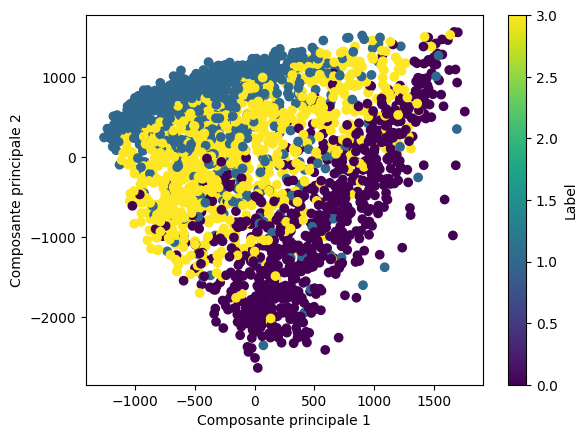

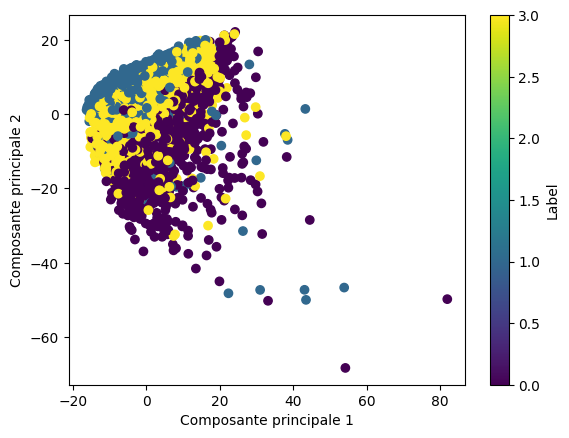

In [16]:
plt.scatter(X_projected[:, 0], X_projected[:, 1], c=y)
plt.xlabel('Composante principale 1')
plt.ylabel('Composante principale 2')
plt.colorbar(label='Label')
plt.show()

plt.scatter(X_projected_1[:, 0], X_projected_1[:, 1], c=y)
plt.xlabel('Composante principale 1')
plt.ylabel('Composante principale 2')
plt.colorbar(label='Label')
plt.show()

3. Changez la couleur des points pour qu'ils soient colorés en fonction de leur classification par un K-clustering de `X` avec 3 clusters. Affichez les images correspondants aux centroïdes.

Convergence atteinte à l'itération 15


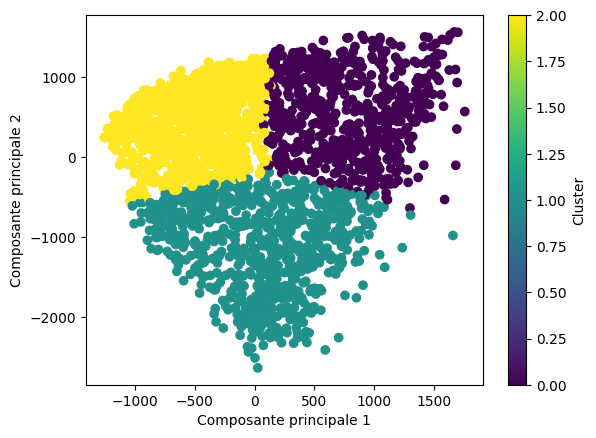

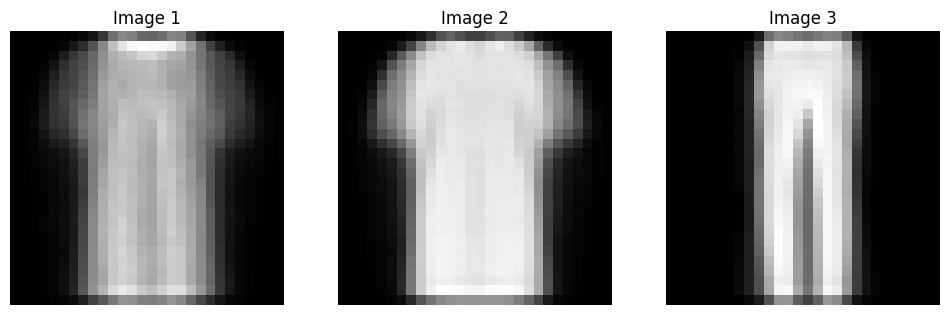

In [17]:
kmeans = MyKMeans(n_clusters=3)
kmeans.fit(X)
labels_kmeans = kmeans.labels
plt.scatter(X_projected[:, 0], X_projected[:, 1], c=labels_kmeans)
plt.xlabel('Composante principale 1')
plt.ylabel('Composante principale 2')
plt.colorbar(label='Cluster')
plt.show()
display_image(kmeans.centroids)

#version  exo  7
# kmeans1 = MyKMeans(n_clusters=3)
# kmeans1.fit(X)
# labels_kmeans1 = kmeans1.labels
# plt.scatter(X_projected_1[:, 0], X_projected_1[:, 1], c=labels_kmeans1)
# plt.xlabel('Composante principale 1')
# plt.ylabel('Composante principale 2')
# plt.colorbar(label='Cluster')
# plt.show()
# display_image(kmeans1.centroids)

4. Enfin, changez la couleur des points pour qu'ils soient colorés en fonction de leur classification par un K-clustering de la projection PCA de `X` en 2 dimensions, avec 3 clusters. Affichez les images correspondants aux centroïdes.

Convergence atteinte à l'itération 16


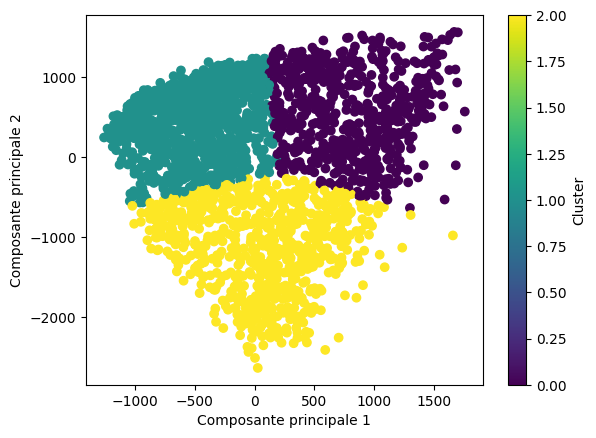

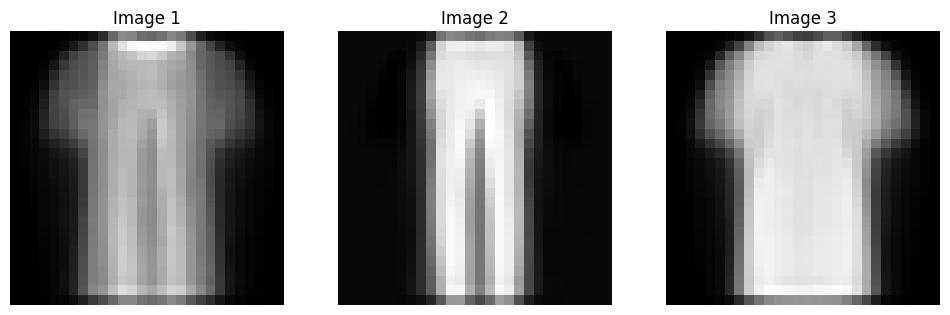

In [24]:
kmeans_pca = MyKMeans(n_clusters=3)
kmeans_pca.fit(X_projected)
labels_kmeans_pca = kmeans_pca.labels
plt.scatter(X_projected[:, 0], X_projected[:, 1], c=labels_kmeans_pca)
plt.xlabel('Composante principale 1')
plt.ylabel('Composante principale 2')
plt.colorbar(label='Cluster')
plt.show()

centroids_pca = kmeans_pca.centroids
centroids_originaux = pca_2.inverse_transform(centroids_pca)
display_image(centroids_originaux)


#version  exo  7
# kmeans_pca_1 = MyKMeans(n_clusters=3)
# kmeans_pca_1.fit(X_projected_1)
# labels_kmeans_pca_1 = kmeans_pca_1.labels
# plt.scatter(X_projected_1[:, 0], X_projected_1[:, 1], c=labels_kmeans_pca_1)
# plt.xlabel('Composante principale 1')
# plt.ylabel('Composante principale 2')
# plt.colorbar(label='Cluster')
# plt.show()

# centroids_pca_1 = kmeans_pca_1.centroids
# centroids_originaux_1 = pca_3.inverse_transform(centroids_pca_1)
# display_image(centroids_originaux_1)

## Exercice 6 

1. Dessinez un graphe calculant la précision (`accuracy`) des labels obtenus par un K-clusterings de la projection PCA de `X` dans ses $i$ premières composantes principales avec 3 clusters, pour $i$ allant de 1 à 40. Utilisez `plt.plot`. 

Convergence atteinte à l'itération 23
Convergence atteinte à l'itération 10
Convergence atteinte à l'itération 23
Convergence atteinte à l'itération 15
Convergence atteinte à l'itération 9
Convergence atteinte à l'itération 10
Convergence atteinte à l'itération 11
Convergence atteinte à l'itération 11
Convergence atteinte à l'itération 30
Convergence atteinte à l'itération 16
Convergence atteinte à l'itération 12
Convergence atteinte à l'itération 17
Convergence atteinte à l'itération 13
Convergence atteinte à l'itération 39
Convergence atteinte à l'itération 11
Convergence atteinte à l'itération 19
Convergence atteinte à l'itération 11
Convergence atteinte à l'itération 24
Convergence atteinte à l'itération 19
Convergence atteinte à l'itération 11
Convergence atteinte à l'itération 15
Convergence atteinte à l'itération 22
Convergence atteinte à l'itération 11
Convergence atteinte à l'itération 12
Convergence atteinte à l'itération 13
Convergence atteinte à l'itération 19
Convergence a

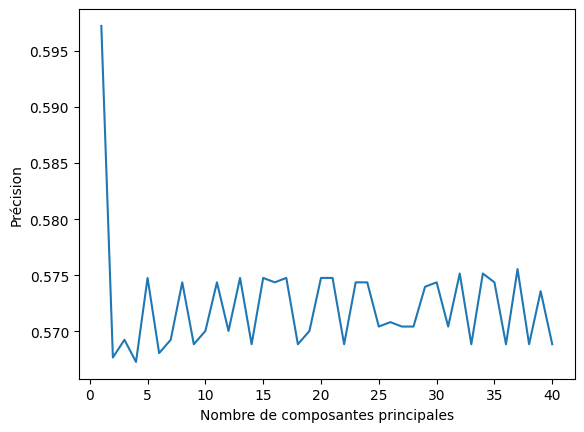

Convergence atteinte à l'itération 14
Convergence atteinte à l'itération 12
Convergence atteinte à l'itération 15
Convergence atteinte à l'itération 16
Convergence atteinte à l'itération 16
Convergence atteinte à l'itération 15
Convergence atteinte à l'itération 17
Convergence atteinte à l'itération 19
Convergence atteinte à l'itération 14
Convergence atteinte à l'itération 18
Convergence atteinte à l'itération 16
Convergence atteinte à l'itération 14
Convergence atteinte à l'itération 16
Convergence atteinte à l'itération 18
Convergence atteinte à l'itération 17
Convergence atteinte à l'itération 20
Convergence atteinte à l'itération 17
Convergence atteinte à l'itération 12
Convergence atteinte à l'itération 16
Convergence atteinte à l'itération 11
Convergence atteinte à l'itération 10
Convergence atteinte à l'itération 20
Convergence atteinte à l'itération 21
Convergence atteinte à l'itération 18
Convergence atteinte à l'itération 30
Convergence atteinte à l'itération 19
Convergence 

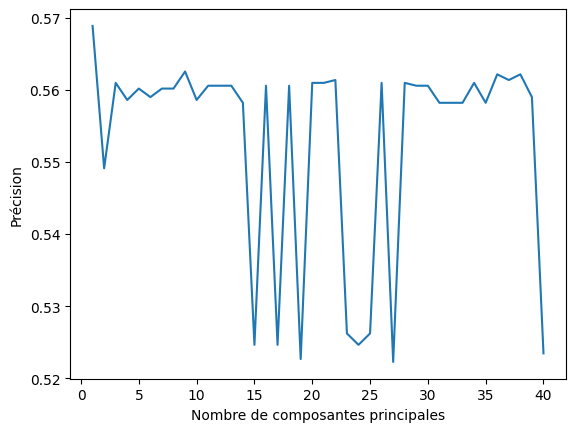

In [25]:
accuracies = []

for i in range(1, 41):
    pca_i = MyPCA(n_components=i)
    pca_i.fit(X)
    X_pca = pca_i.transform(X)
    
    kmeans_i = MyKMeans(n_clusters=3)
    kmeans_i.fit(X_pca)
    
    acc = accuracy(kmeans_i.labels)
    accuracies.append(acc)

plt.plot(range(1, 41), accuracies)
plt.xlabel('Nombre de composantes principales')
plt.ylabel('Précision')
plt.show()

#version_exo7
accuracies_1 = []

for i in range(1, 41):
    pca_i_1 = MyPCA(n_components=i,standardize=True)
    pca_i_1.fit(X)
    X_pca_1 = pca_i_1.transform(X)
    
    kmeans_i_1 = MyKMeans(n_clusters=3)
    kmeans_i_1.fit(X_pca_1)
    
    acc_1 = accuracy(kmeans_i_1.labels)
    accuracies_1.append(acc_1)

plt.plot(range(1, 41), accuracies_1)
plt.xlabel('Nombre de composantes principales')
plt.ylabel('Précision')
plt.show()

2. Faîtes la même chose mais avec 20 clusters.

Convergence atteinte à l'itération 78
Convergence atteinte à l'itération 30
Convergence atteinte à l'itération 18
Convergence atteinte à l'itération 26
Convergence atteinte à l'itération 77
Convergence atteinte à l'itération 26
Convergence atteinte à l'itération 34
Convergence atteinte à l'itération 67
Convergence atteinte à l'itération 54
Convergence atteinte à l'itération 27
Convergence atteinte à l'itération 30
Convergence atteinte à l'itération 22
Convergence atteinte à l'itération 26
Convergence atteinte à l'itération 37
Convergence atteinte à l'itération 31
Convergence atteinte à l'itération 45
Convergence atteinte à l'itération 26
Convergence atteinte à l'itération 22
Convergence atteinte à l'itération 30
Convergence atteinte à l'itération 31
Convergence atteinte à l'itération 28
Convergence atteinte à l'itération 43
Convergence atteinte à l'itération 32
Convergence atteinte à l'itération 64
Convergence atteinte à l'itération 44
Convergence atteinte à l'itération 29
Convergence 

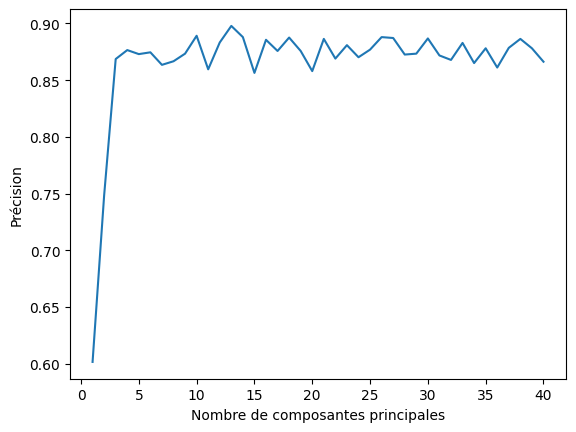

Convergence atteinte à l'itération 76
Convergence atteinte à l'itération 34
Convergence atteinte à l'itération 51
Convergence atteinte à l'itération 30
Convergence atteinte à l'itération 23
Convergence atteinte à l'itération 44
Convergence atteinte à l'itération 28
Convergence atteinte à l'itération 48
Convergence atteinte à l'itération 27
Convergence atteinte à l'itération 74
Convergence atteinte à l'itération 47
Convergence atteinte à l'itération 50
Convergence atteinte à l'itération 64
Convergence atteinte à l'itération 61
Convergence atteinte à l'itération 28
Convergence atteinte à l'itération 36
Convergence atteinte à l'itération 19
Convergence atteinte à l'itération 26
Convergence atteinte à l'itération 38
Convergence atteinte à l'itération 71
Convergence atteinte à l'itération 40
Convergence atteinte à l'itération 36
Convergence atteinte à l'itération 37
Convergence atteinte à l'itération 43
Convergence atteinte à l'itération 48
Convergence atteinte à l'itération 39
Convergence 

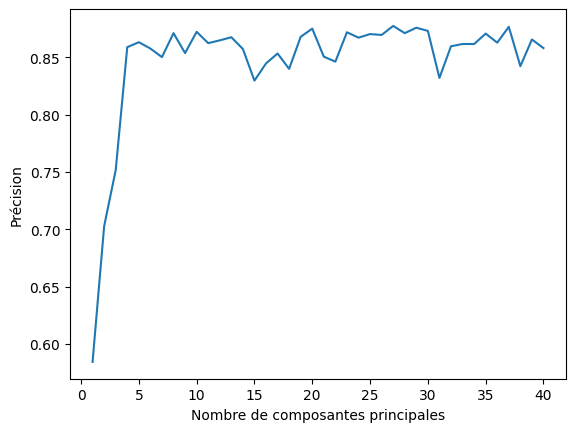

In [ ]:
accuracies = []

for i in range(1, 41):
    pca_i = MyPCA(n_components=i)
    pca_i.fit(X)
    X_pca = pca_i.transform(X)
    
    kmeans_i = MyKMeans(n_clusters=20)
    kmeans_i.fit(X_pca)
    
    acc = accuracy(kmeans_i.labels)
    accuracies.append(acc)

plt.plot(range(1, 41), accuracies)
plt.xlabel('Nombre de composantes principales')
plt.ylabel('Précision')
plt.show()

#version exo 7
accuracies_1 = []

for i in range(1, 41):
    pca_i_1 = MyPCA(n_components=i,standardize=True)
    pca_i_1.fit(X)
    X_pca_1 = pca_i_1.transform(X)
    
    kmeans_i_1 = MyKMeans(n_clusters=20)
    kmeans_i_1.fit(X_pca_1)
    
    acc_1 = accuracy(kmeans_i_1.labels)
    accuracies_1.append(acc_1)

plt.plot(range(1, 41), accuracies_1)
plt.xlabel('Nombre de composantes principales')
plt.ylabel('Précision')
plt.show()


3. Calculez la précision des labels issus d'un K-clustering de `X` avec 100 clusters.

Convergence atteinte à l'itération 15
Convergence atteinte à l'itération 26
Convergence atteinte à l'itération 23
Convergence atteinte à l'itération 21
Convergence atteinte à l'itération 23
Convergence atteinte à l'itération 28
Convergence atteinte à l'itération 23
Convergence atteinte à l'itération 24
Convergence atteinte à l'itération 19
Convergence atteinte à l'itération 23
Convergence atteinte à l'itération 21
Convergence atteinte à l'itération 25
Convergence atteinte à l'itération 15
Convergence atteinte à l'itération 23
Convergence atteinte à l'itération 15
Convergence atteinte à l'itération 17
Convergence atteinte à l'itération 22
Convergence atteinte à l'itération 14
Convergence atteinte à l'itération 22
Convergence atteinte à l'itération 20
Convergence atteinte à l'itération 20
Convergence atteinte à l'itération 23
Convergence atteinte à l'itération 21
Convergence atteinte à l'itération 15
Convergence atteinte à l'itération 18
Convergence atteinte à l'itération 27
Convergence 

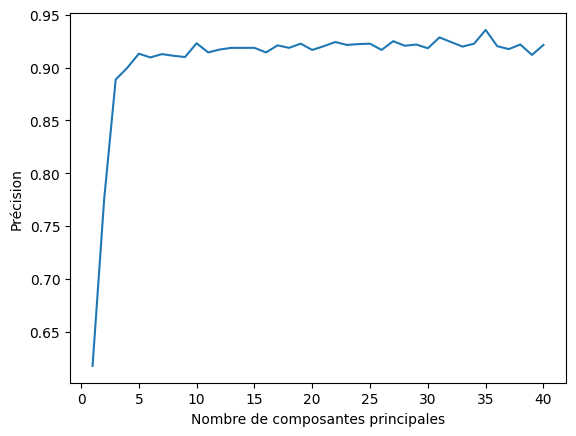

Convergence atteinte à l'itération 29
Convergence atteinte à l'itération 19
Convergence atteinte à l'itération 20
Convergence atteinte à l'itération 20
Convergence atteinte à l'itération 15
Convergence atteinte à l'itération 24
Convergence atteinte à l'itération 26
Convergence atteinte à l'itération 20
Convergence atteinte à l'itération 19
Convergence atteinte à l'itération 19
Convergence atteinte à l'itération 18
Convergence atteinte à l'itération 24
Convergence atteinte à l'itération 26
Convergence atteinte à l'itération 16
Convergence atteinte à l'itération 17
Convergence atteinte à l'itération 26
Convergence atteinte à l'itération 20
Convergence atteinte à l'itération 15
Convergence atteinte à l'itération 24
Convergence atteinte à l'itération 21
Convergence atteinte à l'itération 19
Convergence atteinte à l'itération 18
Convergence atteinte à l'itération 18
Convergence atteinte à l'itération 22
Convergence atteinte à l'itération 23
Convergence atteinte à l'itération 19
Convergence 

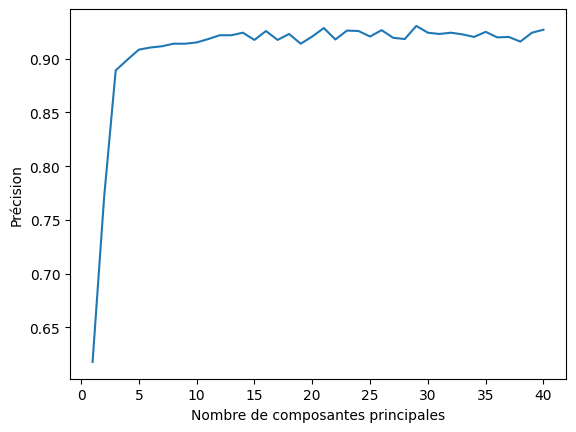

In [27]:
accuracies = []

for i in range(1, 41):
    pca_i = MyPCA(n_components=i)
    pca_i.fit(X)
    X_pca = pca_i.transform(X)
    
    kmeans_i = MyKMeans(n_clusters=100)
    kmeans_i.fit(X_pca)
    
    acc = accuracy(kmeans_i.labels)
    accuracies.append(acc)

plt.plot(range(1, 41), accuracies)
plt.xlabel('Nombre de composantes principales')
plt.ylabel('Précision')
plt.show()


#version exo 7

accuracies_1 = []

for i in range(1, 41):
    pca_i_1 = MyPCA(n_components=i)
    pca_i_1.fit(X)
    X_pca_1 = pca_i_1.transform(X)
    
    kmeans_i_1 = MyKMeans(n_clusters=100)
    kmeans_i_1.fit(X_pca_1)
    
    acc_1 = accuracy(kmeans_i_1.labels)
    accuracies_1.append(acc_1)

plt.plot(range(1, 41), accuracies_1)
plt.xlabel('Nombre de composantes principales')
plt.ylabel('Précision')
plt.show()

4. Calculez la précision des labels issus d'un K-clustering de la projection de `X` dans ses 50 premières composantes principales avec 100 clusters. Même chose avec 100 composantes principales. Qu'observez-vous ?

In [30]:
kmeans_1 = MyKMeans(n_clusters=100)
pca_1 = MyPCA(n_components=50)
pca_1.fit(X)
X_pca_1 = pca_1.transform(X)
kmeans_1.fit(X_pca_1)
acc_1 = accuracy(kmeans_1.labels)
print(acc_1)

kmeans_100 = MyKMeans(n_clusters=100)
pca_100_comp = MyPCA(n_components=100)
pca_100_comp.fit(X)
X_pca_100 = pca_100_comp.transform(X)
kmeans_100.fit(X_pca_100)
acc_100 = accuracy(kmeans_100.labels)
print(acc_100)
# On observe que acc_100 ≈ acc_1 : passer de 50 à 100 composantes n'améliore presque pas la précision
# les 50 premières composantes capturent déjà l'essentiel de l'information
# on peut réduire de 784 à 50 dimensions sans perte significative de performance


kmeans_1_1 = MyKMeans(n_clusters=100)
pca_1_1 = MyPCA(n_components=50,standardize=True)
pca_1_1.fit(X)
X_pca_1_1 = pca_1_1.transform(X)
kmeans_1_1.fit(X_pca_1_1)
acc_1_1 = accuracy(kmeans_1_1.labels)
print(acc_1_1)

kmeans_100_1 = MyKMeans(n_clusters=100)
pca_100_comp_1 = MyPCA(n_components=100,standardize=True)
pca_100_comp_1.fit(X)
X_pca_100_1 = pca_100_comp_1.transform(X)
kmeans_100_1.fit(X_pca_100_1)
acc_100_1 = accuracy(kmeans_100_1.labels)
print(acc_100_1)

Convergence atteinte à l'itération 18
0.9222879684418146
Convergence atteinte à l'itération 28
0.9218934911242603
Convergence atteinte à l'itération 20
0.9124260355029585
Convergence atteinte à l'itération 25
0.914792899408284


## Exercice 7

Refaites les exercices 4, 5 et 6 avec `standardize=True`. Quelles différences observez-vous ? Comment pouvez-vous les expliquer ? Quelle version faut-il choisir ici ?

Quand on utilise (standardize=True), les résultats sont moins bons. Les composantes principales sont moins claires et la précision du clustering est un peu plus faible

Avec (standardize=False), on garde la variance naturelle des pixels, ce qui est important pour les images. Les pixels qui varient beaucoup (comme les contours) donnent plus d'informations que ceux qui varient peu (comme les bords noirs).

Quand on standardise, on donne la même importance à tous les pixels, même ceux qui ne varient presque pas, ce qui n'est pas optimal ici.

Pour ce dataset d'images, il vaut mieux utiliser "standardize=False" parce que tous les pixels sont déjà sur la même échelle (0-255) et les résultats sont meilleurs.

## Exercice 8 

Quels intérêts et quels inconvénients y a t-il à faire son K-clustering sur des données projetées sur ses $n$ premiers composantes principales au lieu de le faire sur les données non-traitées ? Comment choisir $n$ ?

Faire le K-clustering sur les données avec PCA c'est beaucoup plus rapide parce qu'on a moins de dimensions (50 au lieu de 784). Ça enlève aussi le bruit et garde juste l'information importante. La précision reste bonne, parfois même meilleure.

Le seul inconvénient c'est qu'il faut calculer la PCA d'abord et on perd un peu d'info.

Pour choisir n, on peut regarder le graphe de variance et prendre une valeur qui garde environ 80-90% de la variance. Ou sinon on teste plusieurs valeurs et on regarde quand la précision arrête d'augmenter. Dans nos tests, 50 composantes donnent presque le même résultat que 100, donc 50 c'est suffisant.